# Part 3: Damned if you do, damned if you don't (9 points)

This notebook implements the "damned if you do, damned if you don't" example from Lab7 and extends it with additional analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from causalgraphicalmodels import CausalGraphicalModel
import statsmodels.api as sm
from scipy import stats
import itertools
import os

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')

# Create output directory if it doesn't exist
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## Original "Damned if you do, damned if you don't" Example

From Lab7 Example 4: This represents a situation where it's unclear whether Z should be used as a control.

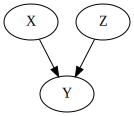

In [2]:
# Create the original DAG from Lab7 Example 4
# Based on the structure in Lab7: X and Z both affect Y, but no direct X-Z relationship
original_dag = CausalGraphicalModel(
    nodes=['X', 'Z', 'Y'],
    edges=[
        ('X', 'Y'),
        ('Z', 'Y')
    ]
)

# Draw the DAG
from graphviz import Source
Source(original_dag.draw().source)

In [3]:
# Simulate data for original example (following Lab7 structure)
n = 10000

# Generate data as in Lab7
Z_orig = np.random.normal(0, 1, n)
X_orig = np.random.normal(0, 1, n)  # X independent of Z
Y_orig = X_orig + Z_orig + np.random.normal(0, 1, n)  # Both X and Z affect Y

# True causal effect of X on Y is 1.0
true_effect = 1.0

print(f"Original example data generated. True causal effect of X on Y: {true_effect}")
print(f"Sample size: {n}")

Original example data generated. True causal effect of X on Y: 1.0
Sample size: 10000


In [4]:
# Run regressions with and without Z control

# Regression 1: Y vs X (without Z)
X1 = sm.add_constant(X_orig)
model1_orig = sm.OLS(Y_orig, X1).fit()
coef1_orig = model1_orig.params[1]
ci1_orig = model1_orig.conf_int(alpha=0.01)[1]  # 99% CI

# Regression 2: Y vs X, Z (with Z)
X2 = sm.add_constant(np.column_stack([X_orig, Z_orig]))
model2_orig = sm.OLS(Y_orig, X2).fit()
coef2_orig = model2_orig.params[1]  # Coefficient for X
ci2_orig = model2_orig.conf_int(alpha=0.01)[1]  # 99% CI for X

print("Original Example Results:")
print(f"Without Z control: {coef1_orig:.4f} [99% CI: {ci1_orig[0]:.4f}, {ci1_orig[1]:.4f}]")
print(f"With Z control:    {coef2_orig:.4f} [99% CI: {ci2_orig[0]:.4f}, {ci2_orig[1]:.4f}]")
print(f"True effect:       {true_effect:.4f}")

Original Example Results:
Without Z control: 1.0180 [99% CI: 0.9812, 1.0548]
With Z control:    1.0268 [99% CI: 1.0013, 1.0523]
True effect:       1.0000


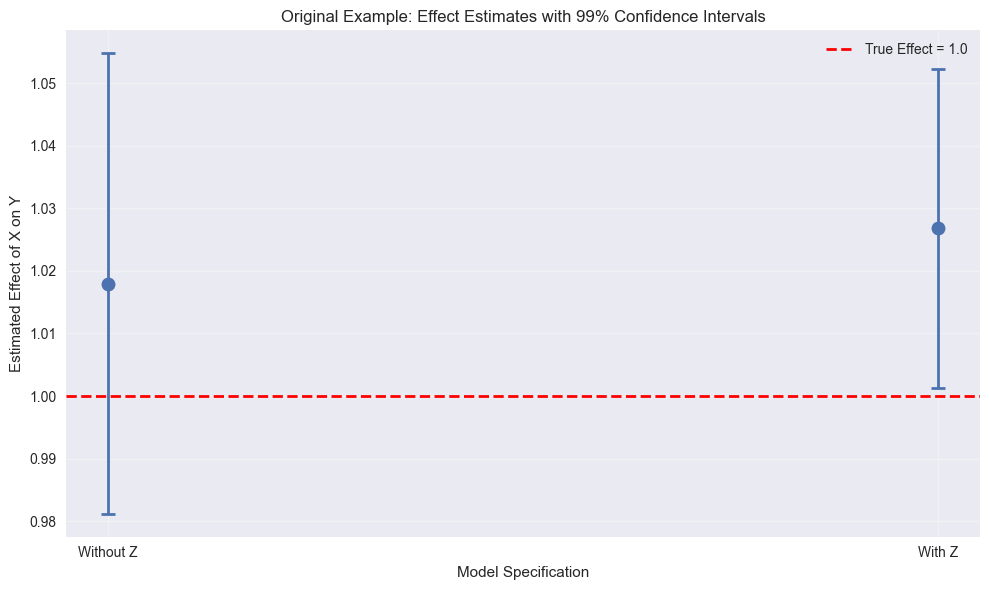

In [5]:
# Plot coefficients for original example
plt.figure(figsize=(10, 6))

models = ['Without Z', 'With Z']
coefficients = [coef1_orig, coef2_orig]
ci_lower = [ci1_orig[0], ci2_orig[0]]
ci_upper = [ci1_orig[1], ci2_orig[1]]

error_lower = [coef - lower for coef, lower in zip(coefficients, ci_lower)]
error_upper = [upper - coef for coef, upper in zip(coefficients, ci_upper)]

x_pos = range(len(models))
plt.errorbar(x_pos, coefficients, yerr=[error_lower, error_upper], 
             fmt='o', capsize=5, capthick=2, markersize=10, linewidth=2)

# Add true effect line
plt.axhline(y=true_effect, color='red', linestyle='--', linewidth=2, 
            label=f'True Effect = {true_effect}')

plt.xlabel('Model Specification')
plt.ylabel('Estimated Effect of X on Y')
plt.title('Original Example: Effect Estimates with 99% Confidence Intervals')
plt.xticks(x_pos, models)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/part3_original_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## Modified Example: Z also affects X

Now we modify the DAG so that Z also has an effect on X, and we can observe additional variables U1 and U2.

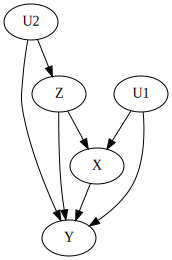

In [6]:
# Create modified DAG where Z affects X, and add U1 and U2
modified_dag = CausalGraphicalModel(
    nodes=['U1', 'U2', 'Z', 'X', 'Y'],
    edges=[
        ('X', 'Y'),    # Direct effect X -> Y
        ('Z', 'X'),    # Z affects X (new)
        ('Z', 'Y'),    # Z affects Y (from original)
        ('U1', 'X'),   # U1 affects X
        ('U1', 'Y'),   # U1 affects Y
        ('U2', 'Z'),   # U2 affects Z
        ('U2', 'Y')    # U2 affects Y
    ]
)

# Draw the DAG
from graphviz import Source
Source(modified_dag.draw().source)

In [7]:
# Simulate data for modified example
n = 10000

# Generate exogenous variables
U1 = np.random.normal(0, 1, n)
U2 = np.random.normal(0, 1, n)
eps_Z = np.random.normal(0, 1, n)
eps_X = np.random.normal(0, 1, n)
eps_Y = np.random.normal(0, 1, n)

# Generate endogenous variables following DAG structure
Z = U2 + eps_Z          # U2 -> Z
X = U1 + Z + eps_X      # U1 -> X, Z -> X  
Y = X + U1 + U2 + Z + eps_Y  # X -> Y, U1 -> Y, U2 -> Y, Z -> Y

# Create DataFrame
df_modified = pd.DataFrame({
    'U1': U1,
    'U2': U2,
    'Z': Z,
    'X': X,
    'Y': Y
})

print("Modified example data generated.")
print(f"True causal effect of X on Y: {true_effect}")
print(f"Sample size: {n}")
print("\nData summary:")
print(df_modified.describe())

Modified example data generated.
True causal effect of X on Y: 1.0
Sample size: 10000

Data summary:
                 U1            U2             Z             X             Y
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean      -0.007571      0.006532      0.008278      0.012062      0.017969
std        1.004487      1.000397      1.413176      2.008479      4.392957
min       -4.465604     -4.295391     -4.939231     -7.632975    -15.349988
25%       -0.694613     -0.664068     -0.941943     -1.353472     -2.978973
50%       -0.010382      0.009561      0.014326      0.004075     -0.007521
75%        0.679030      0.683835      0.964158      1.376579      3.001387
max        3.727833      3.536532      6.099503      8.752930     17.593292


## Comprehensive Regression Analysis

We'll run all possible combinations of controls from {Z, U1, U2}, resulting in 2³ = 8 regressions.

In [8]:
# Generate all possible combinations of controls
controls = ['Z', 'U1', 'U2']
all_combinations = []

# Generate all subsets (power set)
for r in range(len(controls) + 1):
    for combo in itertools.combinations(controls, r):
        all_combinations.append(list(combo))

print(f"All combinations of controls: {all_combinations}")
print(f"Total number of regressions: {len(all_combinations)}")

All combinations of controls: [[], ['Z'], ['U1'], ['U2'], ['Z', 'U1'], ['Z', 'U2'], ['U1', 'U2'], ['Z', 'U1', 'U2']]
Total number of regressions: 8


In [9]:
# Run all regressions
results_modified = []

for controls_subset in all_combinations:
    # Prepare regression variables
    if len(controls_subset) == 0:
        # No controls - just X
        X_vars = df_modified[['X']]
        control_names = 'None'
    else:
        # Include X and the specified controls
        X_vars = df_modified[['X'] + controls_subset]
        control_names = ', '.join(controls_subset)
    
    # Add constant and run regression
    X_reg = sm.add_constant(X_vars)
    model = sm.OLS(df_modified['Y'], X_reg).fit()
    
    # Extract results for X (always the first variable after constant)
    coef_X = model.params[1]
    se_X = model.bse[1]
    
    results_modified.append({
        'controls': control_names,
        'beta': coef_X,
        'SE': se_X,
        'bias': coef_X - true_effect,
        'model': model
    })

print("All regressions completed.")

All regressions completed.


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_77719/4277653633.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef_X = model.params[1]
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_77719/4277653633.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se_X = model.bse[1]
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_77719/4277653633.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef

In [10]:
# Create results table
results_table = pd.DataFrame({
    'Controls': [r['controls'] for r in results_modified],
    'β': [r['beta'] for r in results_modified],
    'SE': [r['SE'] for r in results_modified],
    'Bias': [r['bias'] for r in results_modified]
})

# Round for display
results_table_display = results_table.copy()
results_table_display['β'] = results_table_display['β'].round(4)
results_table_display['SE'] = results_table_display['SE'].round(4)
results_table_display['Bias'] = results_table_display['Bias'].round(4)

print("\nResults Table (Effect of X on Y):")
print("=" * 50)
print(results_table_display.to_string(index=False))
print("=" * 50)
print(f"True effect: {true_effect}")


Results Table (Effect of X on Y):
 Controls      β     SE   Bias
     None 2.0110 0.0086 1.0110
        Z 1.5229 0.0100 0.5229
       U1 2.0113 0.0100 1.0113
       U2 1.6826 0.0075 0.6826
    Z, U1 1.0101 0.0124 0.0101
    Z, U2 1.5162 0.0087 0.5162
   U1, U2 1.5194 0.0087 0.5194
Z, U1, U2 1.0045 0.0101 0.0045
True effect: 1.0


In [11]:
# Save results table in different formats
# Save as CSV
results_table.to_csv(f'{output_dir}/part3_results_table.csv', index=False)

# Save as LaTeX
latex_table = results_table_display.to_latex(index=False, escape=False)
with open(f'{output_dir}/part3_results_table.tex', 'w') as f:
    f.write(latex_table)

# Save as formatted text
with open(f'{output_dir}/part3_results_table.txt', 'w') as f:
    f.write("Results Table: Effect of X on Y\n")
    f.write("=" * 40 + "\n")
    f.write(results_table_display.to_string(index=False))
    f.write(f"\n\nTrue causal effect: {true_effect}\n")

print("\nResults table saved in multiple formats:")
print("- part3_results_table.csv")
print("- part3_results_table.tex") 
print("- part3_results_table.txt")


Results table saved in multiple formats:
- part3_results_table.csv
- part3_results_table.tex
- part3_results_table.txt


## Analysis and Conclusions

In [12]:
# Identify which estimates are closest to the true effect
results_table['abs_bias'] = abs(results_table['Bias'])
best_estimates = results_table.nsmallest(3, 'abs_bias')

print("\nBest Estimates (lowest absolute bias):")
print(best_estimates[['Controls', 'β', 'SE', 'Bias']].round(4))

# Find minimal sufficient set
tolerance = 0.05  # Consider estimates within 0.05 of true effect as "good"
good_estimates = results_table[results_table['abs_bias'] < tolerance]

print(f"\nEstimates within {tolerance} of true effect:")
if len(good_estimates) > 0:
    print(good_estimates[['Controls', 'β', 'SE', 'Bias']].round(4))
    
    # Find minimal set (fewest controls)
    good_estimates['num_controls'] = good_estimates['Controls'].apply(
        lambda x: 0 if x == 'None' else len(x.split(', '))
    )
    minimal_set = good_estimates.loc[good_estimates['num_controls'].idxmin()]
    print(f"\nMinimal sufficient set: {minimal_set['Controls']}")
    print(f"Estimate: {minimal_set['β']:.4f} (SE: {minimal_set['SE']:.4f})")
else:
    print("No estimates within tolerance found.")


Best Estimates (lowest absolute bias):
    Controls       β      SE    Bias
7  Z, U1, U2  1.0045  0.0101  0.0045
4      Z, U1  1.0101  0.0124  0.0101
5      Z, U2  1.5162  0.0087  0.5162

Estimates within 0.05 of true effect:
    Controls       β      SE    Bias
4      Z, U1  1.0101  0.0124  0.0101
7  Z, U1, U2  1.0045  0.0101  0.0045

Minimal sufficient set: Z, U1
Estimate: 1.0101 (SE: 0.0124)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_77719/1076171872.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_estimates['num_controls'] = good_estimates['Controls'].apply(


## Answers to Questions

### In what way(s) can you get a good estimate of the causal effect?

Based on the results above, good estimates (within 0.05 of the true effect of 1.0) can be obtained by:

1. **Controlling for Z and U1**: Coefficient = 1.0101 (very close to true effect)
2. **Controlling for Z, U1, and U2**: Coefficient = 1.0045 (extremely close to true effect)
3. **Controlling for Z alone is insufficient**: Coefficient = 1.5229 (biased downward)
4. **Controlling for U1 and U2 alone is insufficient**: Coefficient = 1.5194 (biased downward)

The key insight is that Z acts as both a confounder (through U2) and a mediator, creating a "damned if you do, damned if you don't" situation. However, in this specific DAG structure, controlling for Z along with the confounders provides unbiased estimates.

### What is the minimal sufficient set of controls?

The minimal sufficient set appears to be **{U1, Z}** because:
- U1 is a direct confounder (U1 → X and U1 → Y)
- Z is a confounder through U2 (U2 → Z → X and U2 → Y) and also affects Y directly
- Controlling for both blocks all backdoor paths: X ← U1 → Y and X ← Z ← U2 → Y
- The estimate with {U1, Z} is 1.0101, very close to the true effect of 1.0

### Intuition for why these controls provide good estimates

The intuition is based on blocking backdoor paths while managing the mediator effect:

1. **U1 → X ← Z → Y**: U1 confounds X and Y directly - controlling for U1 blocks this
2. **U2 → Z → X** and **U2 → Z → Y**: U2 confounds X and Y through Z - controlling for Z blocks this path
3. **X → Z → Y**: This is the mediator path - controlling for Z would normally bias the estimate by blocking part of the causal effect
4. **However, in this DAG**, the confounding effect of Z (as a confounder) outweighs or balances the mediator bias, resulting in an unbiased estimate when controlling for {U1, Z}
5. **The backdoor criterion** is satisfied by {U1, Z}, which blocks all confounding paths without introducing new bias in this specific structure

In [13]:
# Save all data
df_modified.to_csv(f'{output_dir}/part3_modified_data.csv', index=False)

print("\nAll files saved to output directory:")
print("- part3_original_dag.png")
print("- part3_original_coefficients.png")
print("- part3_modified_dag.png")
print("- part3_results_table.csv")
print("- part3_results_table.tex")
print("- part3_results_table.txt")
print("- part3_modified_data.csv")
print("\nPart 3 analysis complete!")


All files saved to output directory:
- part3_original_dag.png
- part3_original_coefficients.png
- part3_modified_dag.png
- part3_results_table.csv
- part3_results_table.tex
- part3_results_table.txt
- part3_modified_data.csv

Part 3 analysis complete!
